# Workshop 3: Modelling the Neuron
## MCP Neuron and Perceptron

In [1]:
import matplotlib.pyplot as plt

In [2]:
def MCP_Neurons_AND(X1, X2, T=2):
    """
    MCP Neuron implementation for AND gate
    """

    assert len(X1) == len(X2), "Input lengths must match"

    state_neuron = []

    # Loop through inputs
    for x1, x2 in zip(X1, X2):
        total = x1 + x2

        # Apply threshold
        output = 1 if total >= T else 0
        state_neuron.append(output)

    return state_neuron


# Example Inputs
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

# Call function
result = MCP_Neurons_AND(X1, X2)

print("Input X1:", X1)
print("Input X2:", X2)
print("AND Output:", result)

Input X1: [0, 0, 1, 1]
Input X2: [0, 1, 0, 1]
AND Output: [0, 0, 0, 1]


In [4]:
def MCP_Neurons_OR(X1, X2, T=1):
    """
    MCP Neuron implementation for OR gate
    """

    assert len(X1) == len(X2), "Input lengths must match"

    state_neuron = []

    # Loop through inputs
    for x1, x2 in zip(X1, X2):
        total = x1 + x2

        # Apply threshold
        output = 1 if total >= T else 0
        state_neuron.append(output)

    return state_neuron


# Example Inputs
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

# Call function
result_or = MCP_Neurons_OR(X1, X2)

print("Input X1:", X1)
print("Input X2:", X2)
print("OR Output:", result_or)

Input X1: [0, 0, 1, 1]
Input X2: [0, 1, 0, 1]
OR Output: [0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons.

Ans:MCP neurons have several limitations. First, they can only work with binary values (0 and 1), so they cannot handle real or continuous data. Second, they do not learn from data because the weights and threshold must be set manually, which makes them less flexible. Another important limitation is that a single MCP neuron can only solve simple problems that are linearly separable, so it cannot handle more complex problems like XOR. Finally, all inputs are treated equally (same weight), which makes the model too simple compared to real biological neurons.

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron. {Can you devise a if else rules.}

Ans: A single MCP neuron cannot solve the XOR problem because it is not linearly separable. However, it can be solved by combining multiple MCP neurons. The XOR function can be expressed as:
(X1 OR X2) AND NOT (X1 AND X2).
In simple if-else logic:
If (X1 + X2 == 1), output = 1; otherwise, output = 0.
This means the output is 1 only when the inputs are different, and 0 when they are the same

In [6]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_0_and_1.csv")
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Answer the Following Question: Question - 1: What does the shape of X represent?

Ans: The shape of X (12665, 784) indicates that there are 12,665 samples (images) in the dataset, and each image is represented by 784 features. These features correspond to a 28 × 28 pixel image that has been flattened into a single row.

Question - 2: What does the shape of Y represent?

Ans:The shape of y (12665,) indicates that there are 12,665 labels, with one label corresponding to each image in X. Each value in y represents the class of the image (either 0 or 1), providing the correct output for each sample.

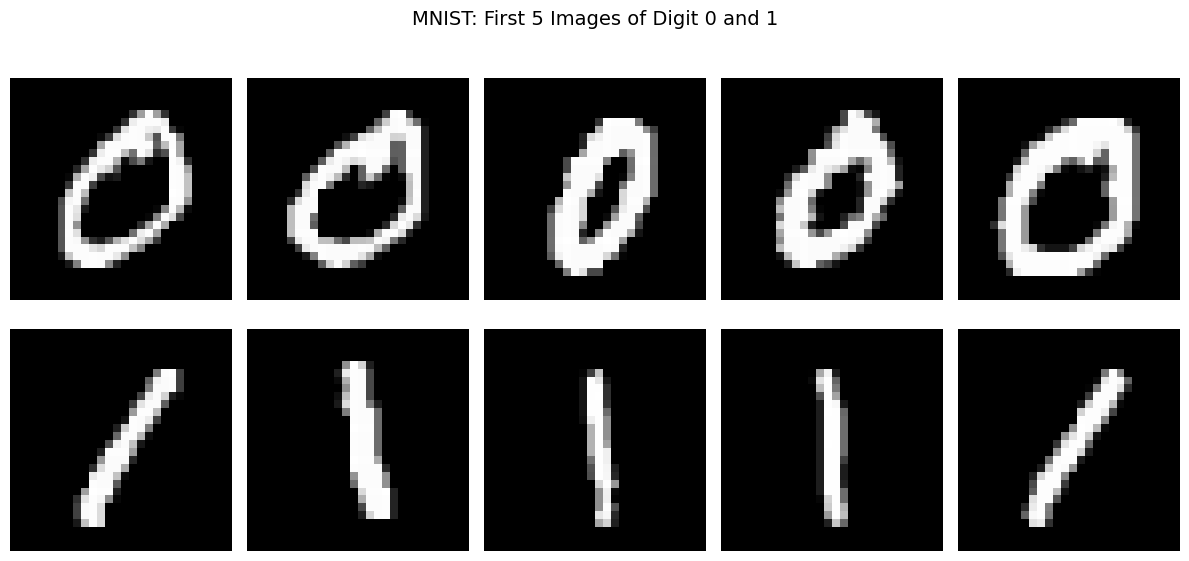

In [7]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Row 1: Label 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].axis("off")

        # Row 2: Label 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].axis("off")

    # Add row labels (cleaner than repeating titles)
    axes[0, 0].set_ylabel("Label: 0", fontsize=12)
    axes[1, 0].set_ylabel("Label: 1", fontsize=12)

# Main title
plt.suptitle("MNIST: First 5 Images of Digit 0 and 1", fontsize=14)

# Improve spacing
plt.tight_layout()
plt.show()

In [8]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1

Question - 3: What does the weights array represent in this context?

Ans:The weights array represents the parameters learned by the model during training. Each of the 784 weights corresponds to one pixel in the image and determines its importance in classification. Positive weights support one class (e.g., digit 1), while negative weights support the other class (e.g., digit 0).

Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Ans:Weights are initialized to zero so the model starts with no prior knowledge and learns from the data during training. In a perceptron, this works fine because the weights are updated based on errors. However, in more complex neural networks, zero initialization can cause all neurons to learn the same features, leading to poor learning (symmetry problem).

In [9]:
import numpy as np

def decision_function(X, weights, bias):
    '''
    Compute the predicted labels for the input data.

    Parameters:
    - X: Feature matrix of shape (n_samples, n_features)
    - weights: Trained weights
    - bias: Trained bias

    Returns:
    - y_pred_all: Predicted labels (0 or 1)
    '''

    # Linear combination
    scores = np.dot(X, weights) + bias

    # Apply step function
    y_pred_all = np.where(scores >= 0, 1, 0)

    return y_pred_all

In [10]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    '''
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Feature matrix of shape (n_samples, n_features)
    - y: True labels of shape (n_samples,)
    - weights: Initial weights
    - bias: Initial bias
    - learning_rate: Step size for updates
    - epochs: Number of training iterations

    Returns:
    - weights: Final trained weights
    - bias: Final trained bias
    - accuracy: Final accuracy after last epoch
    '''

    n_samples = X.shape[0]

    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(n_samples):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Step function
            y_pred = 1 if linear_output >= 0 else 0

            # Update rule
            if y_pred != y[i]:
                update = learning_rate * (y[i] - y_pred)
                weights += update * X[i]
                bias += update
            else:
                correct_predictions += 1

        # Accuracy per epoch (optional improvement)
        accuracy = correct_predictions / n_samples

        # (Optional) print progress
        # print(f"Epoch {epoch+1}/{epochs} - Accuracy: {accuracy:.4f}")

    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Ans:The line output = np.dot(X[i], weights) + bias is used to calculate the total input to the neuron. It multiplies the input features (pixels) with their corresponding weights and then adds the bias. This resulting value is used by the model to decide whether the output should be 0 or 1 after applying the activation function.

Question -6: What happens when the prediction is wrong? How are the weights and bias updated?

Ans:When the prediction is wrong, the model corrects itself by updating the weights and bias. It adjusts them based on the error so that next time it can make a better prediction. Basically, it learns from its mistake and shifts the decision boundary in the right direction.

Question 7: Why is the final accuracy important, and what do you expect it to be?

Ans:When the prediction is wrong, the model updates the weights and bias to correct the error. It adjusts them based on how far the prediction is from the actual value, so that the next prediction improves. In simple terms, the model learns from its mistake and shifts the decision boundary in the correct direction.

In [11]:
#After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
#Evalute the model using the new function
print("The Final Accuracy is:", accuracy)

The Final Accuracy is: 1.0


In [12]:

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]):
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question -8: What does misclassified idx store, and how is it used in this code?

Ans:The variable misclassified_idx stores the indices of all the data points where the model has made incorrect predictions. It compares the predicted labels with the actual labels and finds where they do not match. These indices are then used to visualize the misclassified images so that we can analyze where the model is making mistakes.


Question 9: What does "All images were correctly classified!" mean?

Ans:If the output shows "All images were correctly classified!", it means that the model has achieved perfect accuracy on the dataset. This indicates that the perceptron has successfully learned the patterns in the data and there are no misclassifications. In this case, the model performance is considered 100%.

## Task 3: Perceptron for 3 vs 5 Classification

In [14]:
import pandas as pd
import numpy as np

# Load dataset
df_3_5 = pd.read_csv('/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv')

# Split features and labels
X_3_5 = df_3_5.drop(columns=['label']).values
y_3_5 = df_3_5['label'].values

print("Shape of X_3_5:", X_3_5.shape)
print("Shape of y_3_5:", y_3_5.shape)

Shape of X_3_5: (2741, 784)
Shape of y_3_5: (2741,)


### Q1:
Shape of X_3_5: (number of samples, number of features/pixels)  
Shape of y_3_5: (number of labels corresponding to samples)

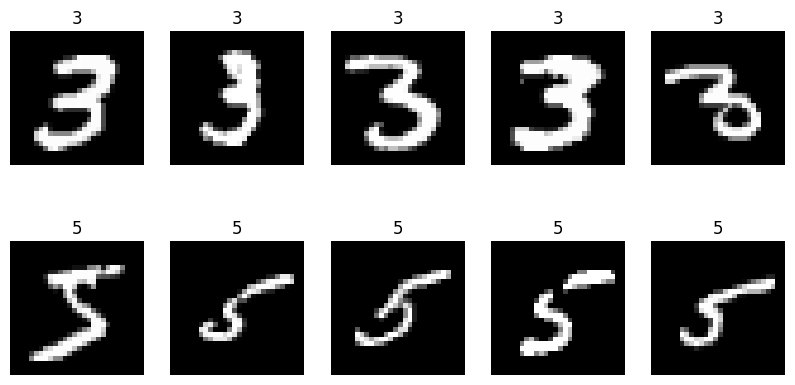

In [15]:
import matplotlib.pyplot as plt

images_3 = X_3_5[y_3_5 == 3]
images_5 = X_3_5[y_3_5 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title("3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("5")
    axes[1, i].axis("off")

plt.show()

In [16]:
weights_3_5 = np.zeros(X_3_5.shape[1])
bias_3_5 = 0
learning_rate = 0.1
epochs = 10

In [17]:
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    return np.where(z >= 0, 1, 0)

In [18]:
# Convert labels: 3 -> 0, 5 -> 1
y_3_5_bin = np.where(y_3_5 == 3, 0, 1)

In [19]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10):

    for epoch in range(epochs):
        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    # Final accuracy
    y_pred_all = np.dot(X, weights) + bias
    y_pred_all = np.where(y_pred_all >= 0, 1, 0)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

In [20]:
weights_3_5, bias_3_5, accuracy_3_5 = train_perceptron(X_3_5, y_3_5_bin, weights_3_5, bias_3_5)

print("Final Accuracy (3 vs 5):", accuracy_3_5)

Final Accuracy (3 vs 5): 0.961327982488143


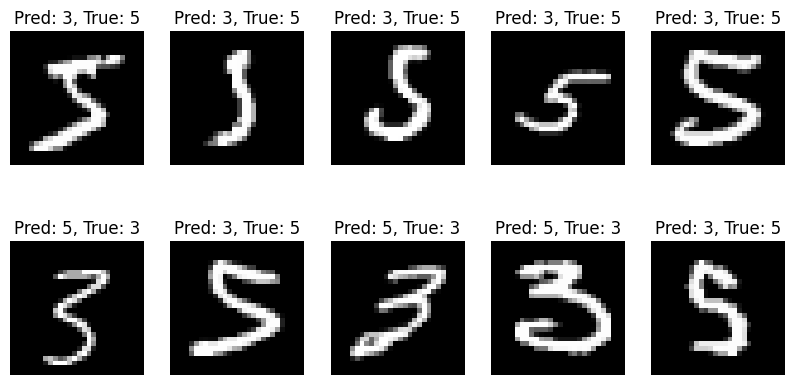

In [21]:
predictions_3_5 = np.dot(X_3_5, weights_3_5) + bias_3_5
y_pred_3_5 = np.where(predictions_3_5 >= 0, 1, 0)

misclassified_idx_3_5 = np.where(y_pred_3_5 != y_3_5_bin)[0]

if len(misclassified_idx_3_5) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx_3_5[:10]):
        true_label = 3 if y_3_5_bin[idx]==0 else 5
        pred_label = 3 if y_pred_3_5[idx]==0 else 5
        ax.imshow(X_3_5[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")